In [1]:
import sys
sys.path.append('../')
sys.path.append("../../")
import numpy as np
import matplotlib.pyplot as plt
import os

from DoseEngines import ModelConfig
from models.layers import *
from models.utils.data import DataGenerator
from models.utils.plotting import *
from models.utils.kernel import *

/home/bolo/anaconda3/envs/autoplan/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-08-11 08:53:58.282755: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-11 08:53:58.324019: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-11 08:53:58.995407: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
if (os.path.exists('/mnt/')):
  data_path = '/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/DATASETS/ARTP/'
if (os.path.exists('/data/')):
  data_path = '/data/attila/matrad'
if (os.path.exists('/mimer/')):
  data_path = '/mimer/NOBACKUP/groups/naiss2023-6-64/matrad'

gen = DataGenerator(data_path, "training", False, 1)
x, y = gen[0]

Number of files: 2379 in training cohort


Displaying sample 6 / 2379 (MIQA_0334276fd9f_0_3.npz)


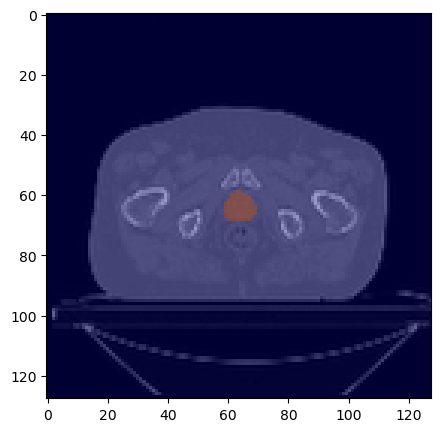

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

for i, (x, y) in enumerate(gen):  # Loop through the generator
    clear_output(wait=True)  # Clear the previous image
    print(f"Displaying sample {i+1} / {len(gen)} ({gen.file_list[i]})")  # Print the current sample number
    
    plt.figure(figsize=(10, 5))

    # Gray image
    plt.imshow(x[0, :, :, 160, 0], cmap="gray")
    plt.imshow(x[0, :, :, 160, 1], cmap="jet", alpha=0.4)
    plt.show()
    
    time.sleep(0.1)  # Pause for 5 seconds before moving to the next one
    if i == 5:
        break  # Stop after 10 samples


(1, 128, 128, 320, 8) (1, 128, 128, 320)
-1.0 12.074345


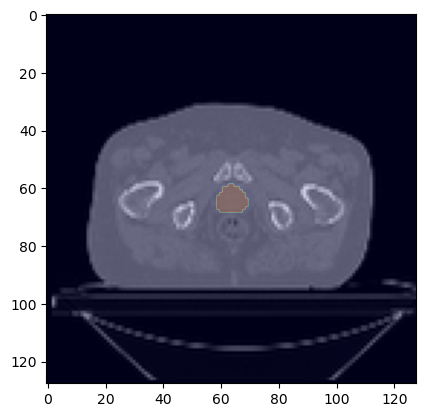

In [4]:
x, y = gen[0]
print(x.shape, y.shape)
print(np.min(x), np.max(x))

plt.imshow(x[0, :, :, 160, 0], cmap="gray")
plt.imshow(x[0, :, :, 160, 1], cmap="jet", alpha=0.2)

In [5]:
config = ModelConfig(ct_array_shape=(128, 128, 320), resolution=(0.2, 0.2, 0.2), downsampling_factor=(1, 1, 1), field_size=(3, 3), number_of_leaf_pairs=60, tpr_20_10=0.72, number_of_cps=5)

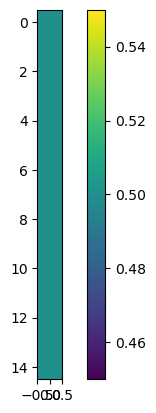

/home/bolo/Documents/autoplan/notebooks/examples/../../models/layers/FluenceVolumeLayer.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  corrected = resized * torch.tensor(correction, device=self.device).detach()


(5, 128, 128, 320, 1)


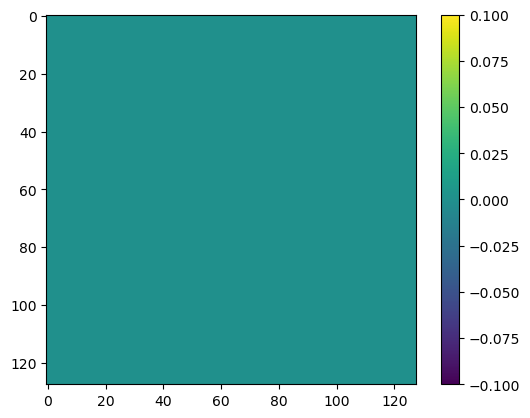

Depth: 0.0	width: 0.0
Depth: 2.0	width: 0.0
Depth: 4.0	width: 0.0
Depth: 6.0	width: 0.0
Depth: 8.0	width: 0.0
Depth: 10.0	width: 0.0
Depth: 12.0	width: 0.0
Depth: 14.0	width: 0.0
Depth: 16.0	width: 0.0
Depth: 18.0	width: 0.0
Depth: 20.0	width: 0.0
Depth: 22.0	width: 0.0
Depth: 24.0	width: 0.0


In [6]:
fluence_map_layer = FluenceMapLayer(config, slope=100.0)  # Instantiate the FluenceMapLayer
fluence_volume_layer = FluenceVolumeLayer(config)  # Instantiate the FluenceVolumeLayer with config

y_mlc = torch.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs)).to("cuda")
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
fluence_map = fluence_map_layer(y_mlc)

plt.imshow(fluence_map.detach().cpu().numpy()[0, 0, :, :])
plt.colorbar()
plt.show()
fluence_volume = fluence_volume_layer(fluence_map).detach().cpu().numpy()
print(np.shape(fluence_volume))
plt.imshow(fluence_volume[0, :, :, 80, 0], interpolation='none')
plt.colorbar()
plt.show()
for i in range(0, fluence_volume.shape[1], 10):
    print(f"Depth: {i * config.resolution[0]}\twidth: {np.sum(fluence_volume[0, i, 32, :, 0] > 0) * config.resolution[2]}")

In [10]:
x_ct = torch.stack([x[..., 0], x[..., 0]], 0)
y_mlc = torch.zeros((2, 2, config.number_of_cps, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 0.5
mus = np.array(0.1 * torch.ones((2, config.number_of_cps)), dtype=torch.float32) * 100
dose_layer = AccumulateDose3DLayer(config, 5)

# print(np.unique(dose))

TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray

In [8]:
dose = dose_layer(x_ct, y_mlc, mus).detach().cpu().numpy()

TypeError: clamp() received an invalid combination of arguments - got (numpy.ndarray, float), but expected one of:
 * (Tensor input, Tensor min = None, Tensor max = None, *, Tensor out = None)
 * (Tensor input, Number min = None, Number max = None, *, Tensor out = None)


In [ ]:
np.argmax(np.sum(dose, (0, 1)))

In [ ]:
print(dose.shape)

slice_idx = 160
# plt.imshow(x_ct[1, :, :, slice_idx], cmap="gray")
plt.imshow(dose[1, :, :, 160], cmap='jet')#, alpha=0.2)
plt.colorbar()
# plt.axis('off')
plt.show()

In [ ]:
print(dose.shape)

slice_idx = 160
plt.imshow(x_ct[1, :, 64, :], cmap="gray")
plt.imshow(dose[0, :, 64, :], cmap='jet', alpha=0.2)
plt.colorbar()
# plt.axis('off')
plt.show()